In [ ]:
pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.9 MB/s eta 0:00:00


In [ ]:
!pip install torch

In [ ]:
!pip install shap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import torch
import shap

from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from pytorch_tabnet.callbacks import Callback

In [ ]:
sns.set_style('whitegrid')
sns.set_theme('notebook')

# =============================================================================
# 1. LOAD DATA
# =============================================================================

df = pd.read_csv('Telco-Customer-Churn.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())


Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Str

In [ ]:
# =============================================================================
# 2. DATA CLEANING
# =============================================================================

df.drop(columns=['customerID'], inplace=True)


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("\nMissing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])


df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)

print("\nMissing values after cleaning:")
print(df.isnull().sum().sum(), "missing values remaining")
print("\nData types:\n", df.dtypes)
print("\nClass balance:\n", df['Churn'].value_counts())



Missing values before cleaning:
TotalCharges    11
dtype: int64

Missing values after cleaning:
0 missing values remaining

Data types:
 gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

Class balance:
 Churn
0    5174
1    1869
Name: count, dtype: int64


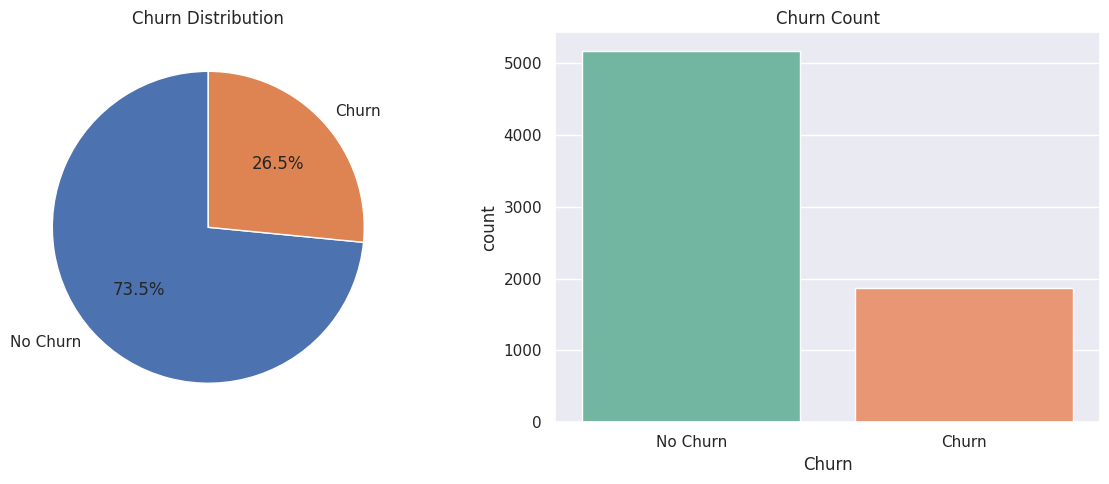

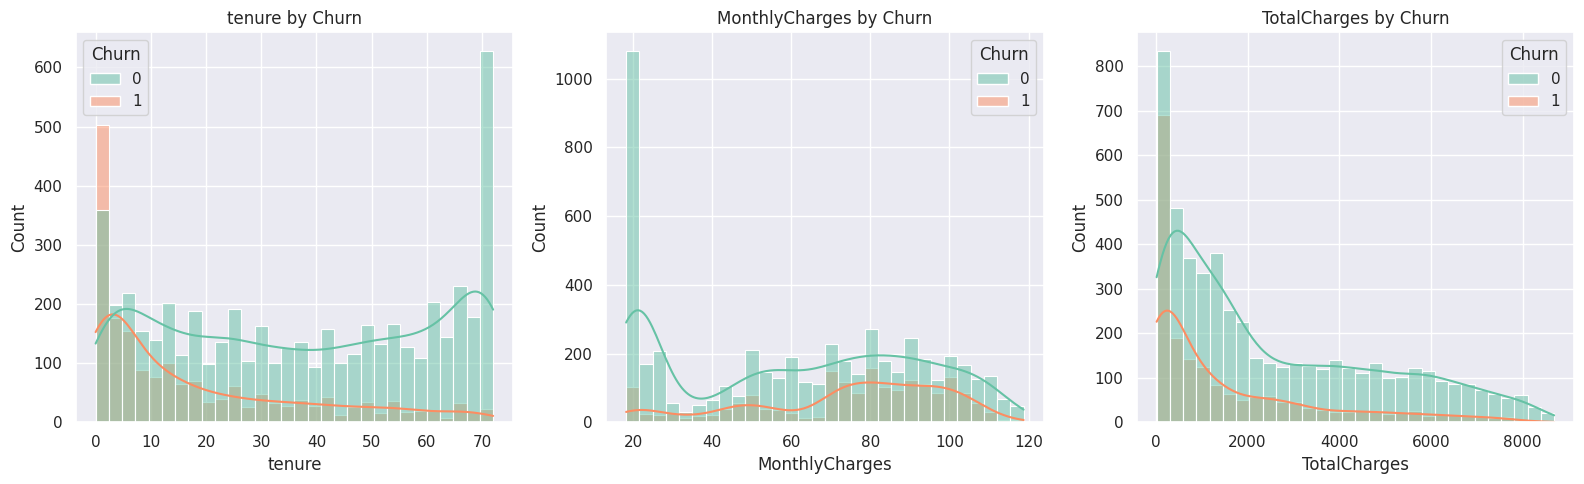

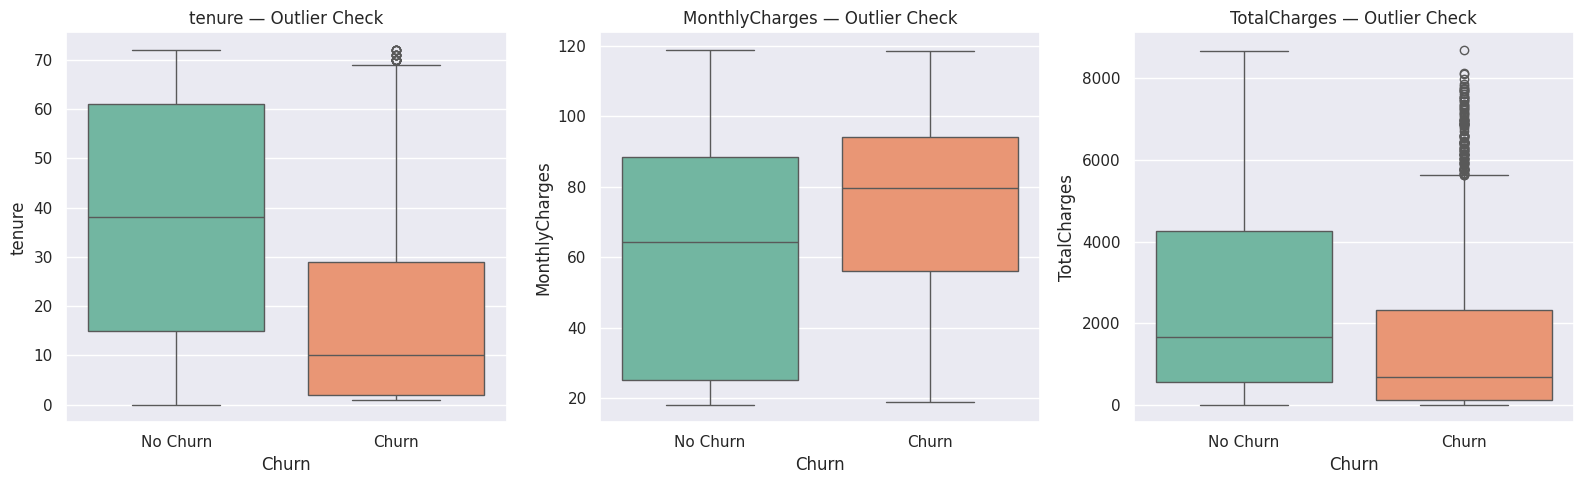

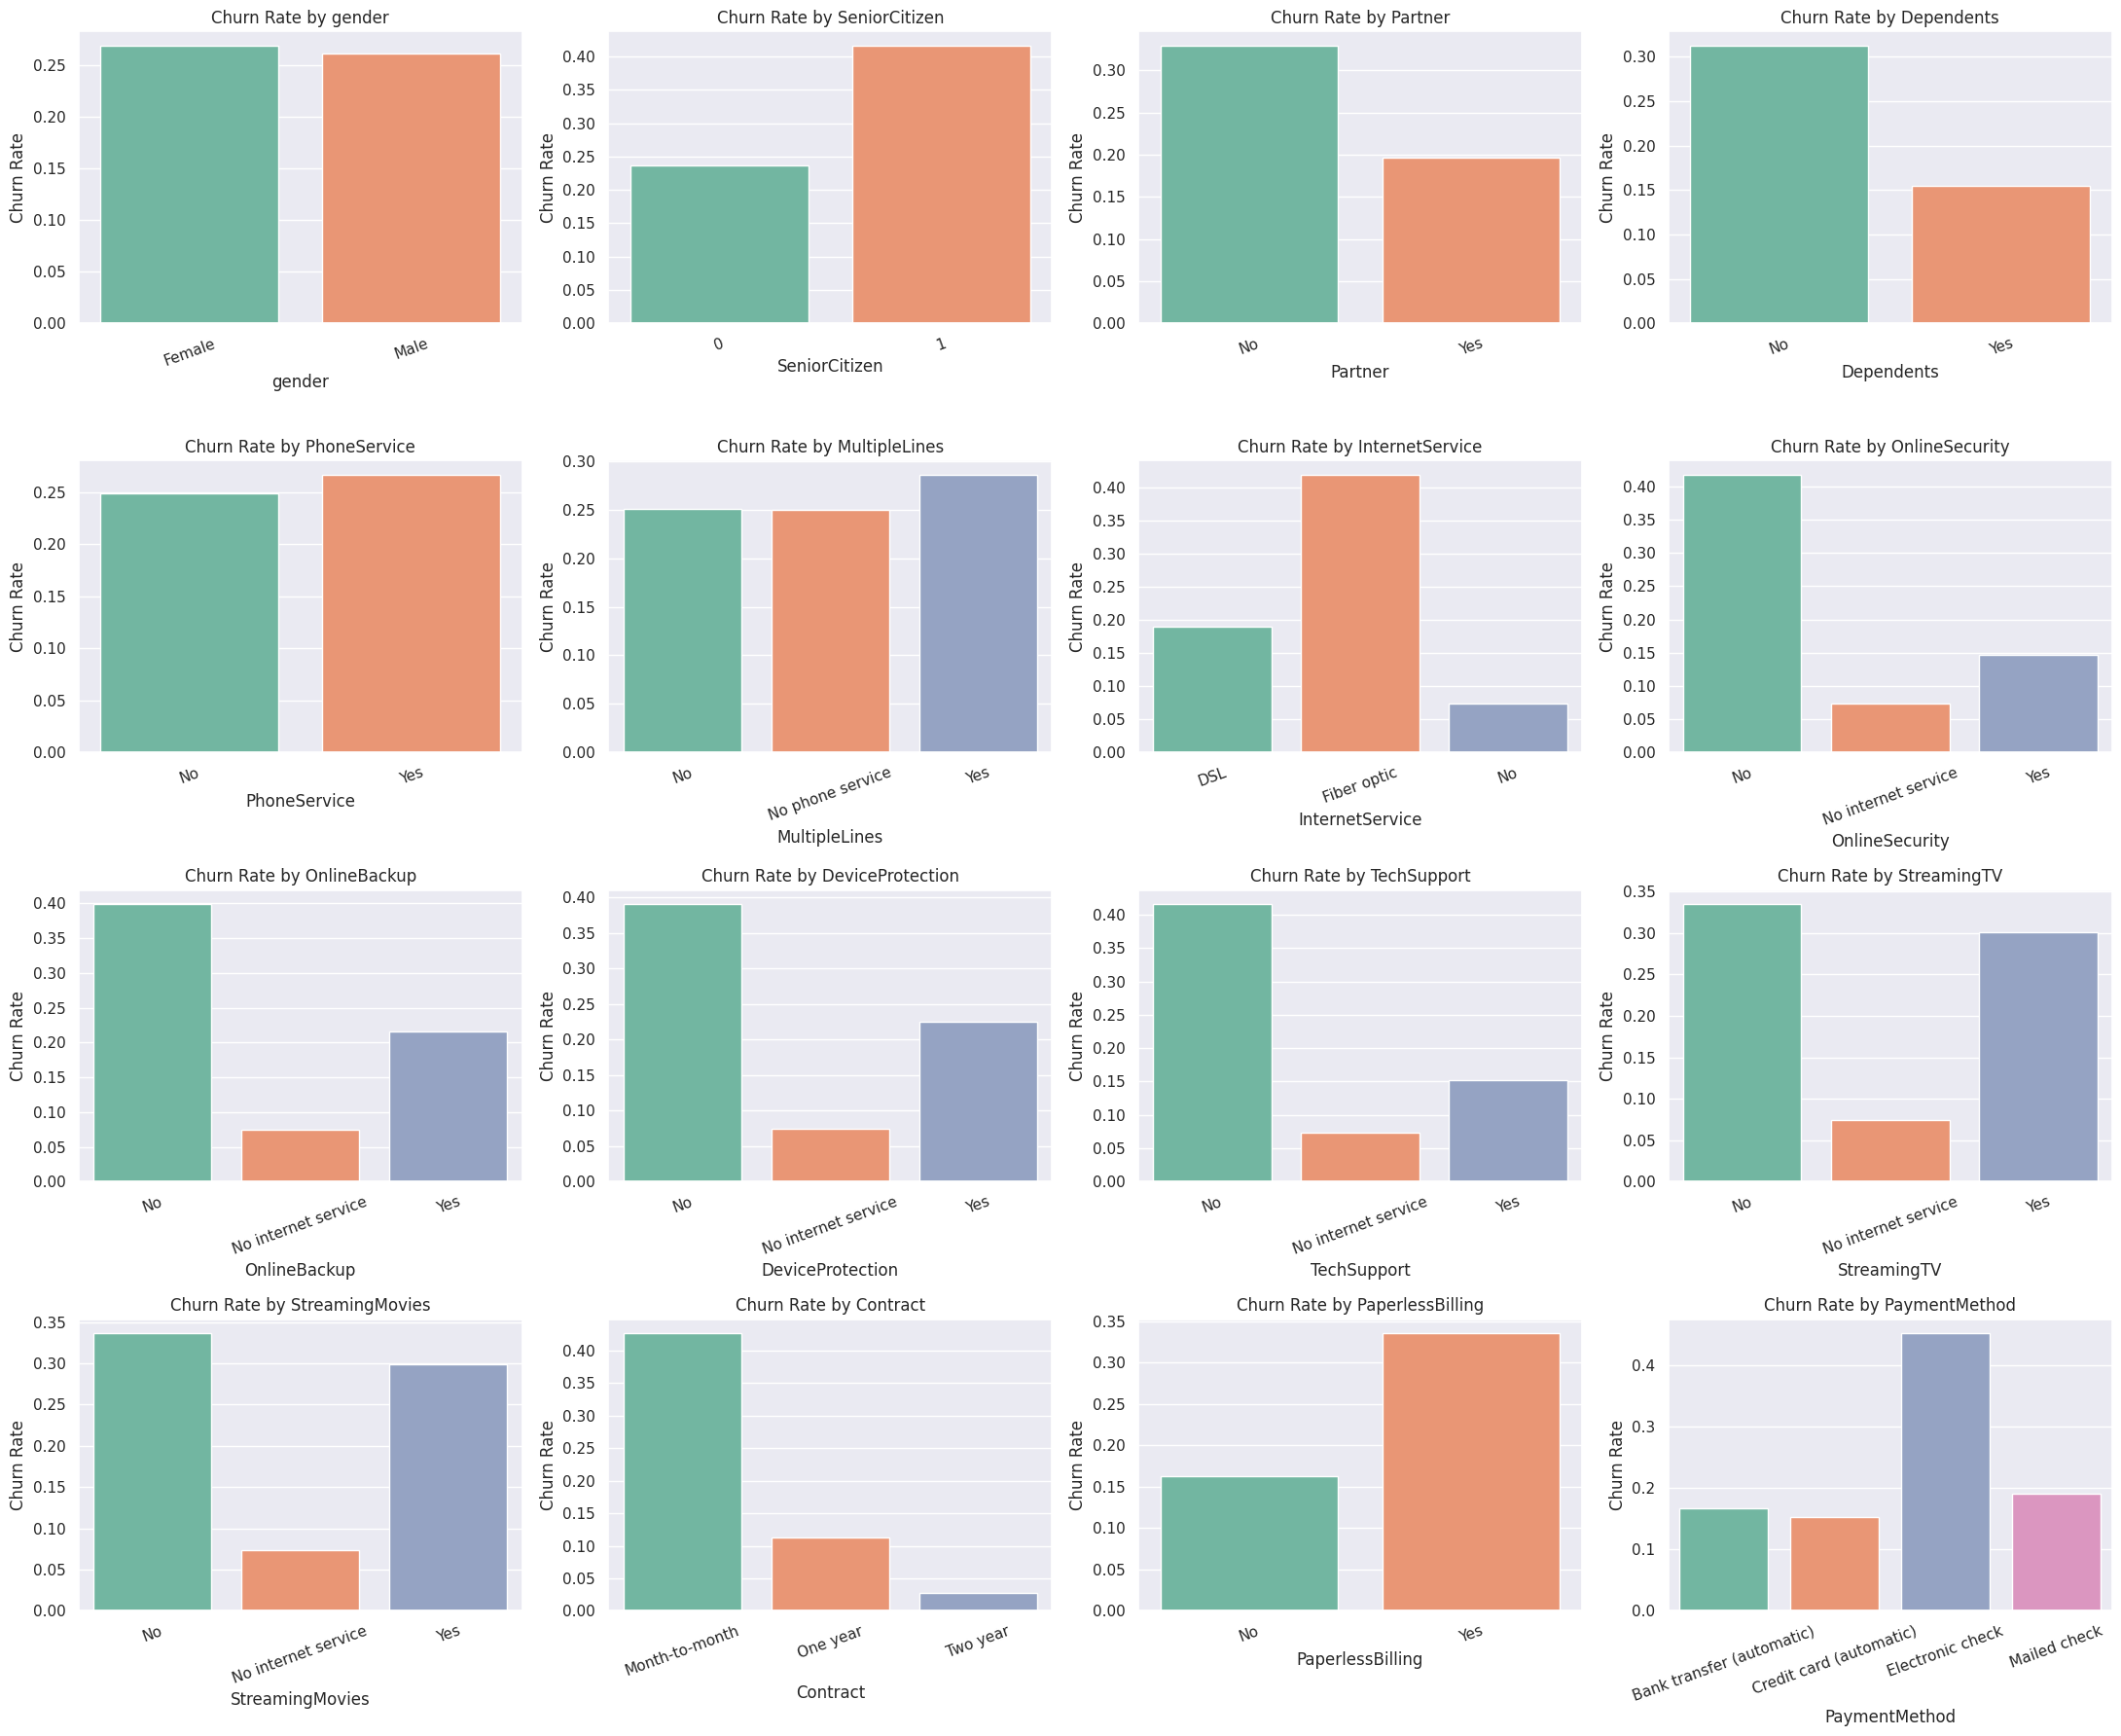

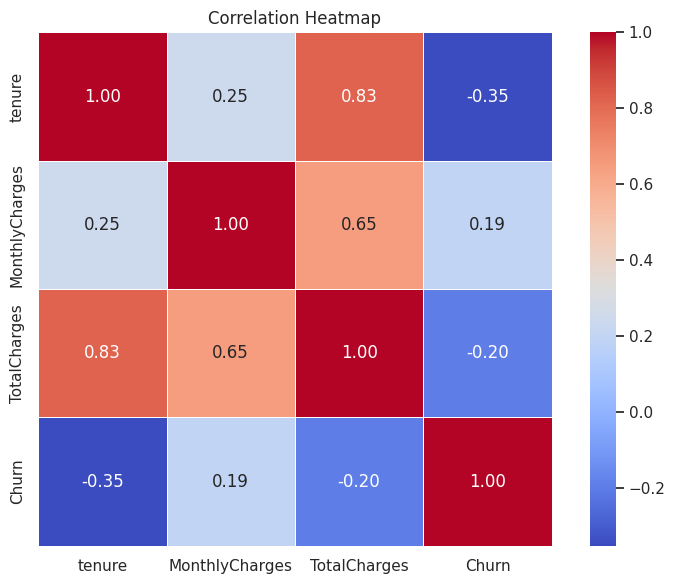

In [ ]:
# =============================================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Churn'].value_counts().plot.pie(
    autopct='%1.1f%%', labels=['No Churn', 'Churn'],
    colors=['#4C72B0', '#DD8452'], startangle=90, ax=axes[0]
)
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('')

sns.countplot(x='Churn', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Churn Count')
axes[1].set_xticklabels(['No Churn', 'Churn'])
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Numerical Features Distribution ---
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True,
                 palette='Set2', bins=30, ax=axes[i])
    axes[i].set_title(f'{col} by Churn')
plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Boxplots for Outlier Detection ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Churn', y=col, palette='Set2', ax=axes[i])
    axes[i].set_xticklabels(['No Churn', 'Churn'])
    axes[i].set_title(f'{col} — Outlier Check')
plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Categorical Features vs Churn ---
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(22, 18))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().reset_index()
    sns.barplot(data=churn_rate, x=col, y='Churn',
                palette='Set2', ax=axes[i])
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('categorical_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Correlation Heatmap  ---
plt.figure(figsize=(8, 6))
corr = df[num_cols + ['Churn']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
# =============================================================================
# 4. FEATURE ENGINEERING
# =============================================================================

df_fe = df.copy()

# --- 4.1 New Features ---

# Average monthly spend relative to tenure (avoids div-by-zero)
df_fe['AvgMonthlySpend'] = df_fe['TotalCharges'] / (df_fe['tenure'] + 1)

# Engagement score: number of add-on services subscribed
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']
# These cols have values: 'Yes', 'No'
for col in addon_cols:
    df_fe[col + '_bin'] = (df_fe[col] == 'Yes').astype(int)

df_fe['AddonCount'] = df_fe[[c + '_bin' for c in addon_cols]].sum(axis=1)

# Tenure bucket (bins: new, mid, long-term)
df_fe['TenureBucket'] = pd.cut(df_fe['tenure'],
                                bins=[0, 12, 36, 72],
                                labels=['New', 'Mid', 'LongTerm'])

# High spender flag (above median monthly charges)
median_charge = df_fe['MonthlyCharges'].median()
df_fe['HighSpender'] = (df_fe['MonthlyCharges'] > median_charge).astype(int)

print("\nNew features added: AvgMonthlySpend, AddonCount, TenureBucket, HighSpender")
print(df_fe[['AvgMonthlySpend', 'AddonCount', 'TenureBucket', 'HighSpender']].head())



New features added: AvgMonthlySpend, AddonCount, TenureBucket, HighSpender
   AvgMonthlySpend  AddonCount TenureBucket  HighSpender
0        14.925000           1          New            0
1        53.985714           2          Mid            0
2        36.050000           2          New            0
3        40.016304           3     LongTerm            0
4        50.550000           0          New            1


In [ ]:
# =============================================================================
# 5. PREPARE FEATURES & TARGET — PIPELINE
# =============================================================================

# Separate target
X = df_fe.drop(columns='Churn')
y = df_fe['Churn']

# Drop original addon cols (replaced by binaries) and tenure (bucketed)
X.drop(columns=addon_cols, inplace=True)

# Define feature groups
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges',
                      'AvgMonthlySpend', 'AddonCount']

binary_features = ['SeniorCitizen', 'HighSpender'] + [c + '_bin' for c in addon_cols]

categorical_features = ['gender', 'Partner', 'Dependents',
                        'PhoneService', 'MultipleLines', 'InternetService',
                        'Contract', 'PaperlessBilling', 'PaymentMethod',
                        'TenureBucket']

# --- Pipelines ---
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Binary features only need imputation (already 0/1)
bin_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_features),
    ('cat', cat_pipeline, categorical_features),
    ('bin', bin_pipeline, binary_features)
])

# --- Fit & Transform ---
X_preprocessed = preprocessor.fit_transform(X)

# --- Recover feature names ---
ohe_cols = preprocessor.named_transformers_['cat']['encoder']\
               .get_feature_names_out(categorical_features).tolist()
all_feature_names = numerical_features + ohe_cols + binary_features

preprocessed_df = pd.DataFrame(X_preprocessed, columns=all_feature_names)
preprocessed_df['Churn'] = y.values

print("\nPreprocessed DataFrame shape:", preprocessed_df.shape)
print(preprocessed_df.head())


Preprocessed DataFrame shape: (7043, 40)
     tenure  MonthlyCharges  TotalCharges  AvgMonthlySpend  AddonCount  \
0 -1.277445       -1.160323     -0.994242        -0.757979   -0.561776   
1  0.066327       -0.259629     -0.173244        -0.117801   -0.020519   
2 -1.236724       -0.362660     -0.959674        -0.411755   -0.020519   
3  0.514251       -0.746535     -0.194766        -0.346750    0.520738   
4 -1.236724        0.197365     -0.940470        -0.174110   -1.103033   

   gender_Female  gender_Male  Partner_No  Partner_Yes  Dependents_No  ...  \
0            1.0          0.0         0.0          1.0            1.0  ...   
1            0.0          1.0         1.0          0.0            1.0  ...   
2            0.0          1.0         1.0          0.0            1.0  ...   
3            0.0          1.0         1.0          0.0            1.0  ...   
4            1.0          0.0         1.0          0.0            1.0  ...   

   TenureBucket_New  SeniorCitizen  HighSpen

In [ ]:
# =============================================================================
# 6. SAVE — Ready for SageMaker (CSV, target column first)
# =============================================================================

# SageMaker built-in algorithms expect target as the FIRST column
sagemaker_df = preprocessed_df[['Churn'] + [c for c in preprocessed_df.columns if c != 'Churn']]
sagemaker_df.to_csv('telco_churn_preprocessed.csv', index=False, header=False)

print("\n✅ Saved: telco_churn_preprocessed.csv")
print("Shape:", sagemaker_df.shape)
print("\nUpload this file to your S3 bucket using:")
print("""
import boto3
s3 = boto3.client('s3')
s3.upload_file(
    'telco_churn_preprocessed.csv',
    'your-bucket-name',
    'data/telco_churn_preprocessed.csv'
)
print('Upload complete.')
""")



✅ Saved: telco_churn_preprocessed.csv
Shape: (7043, 40)

Upload this file to your S3 bucket using:

import boto3
s3 = boto3.client('s3')
s3.upload_file(
    'telco_churn_preprocessed.csv',
    'your-bucket-name',
    'data/telco_churn_preprocessed.csv'
)
print('Upload complete.')



In [ ]:
# =============================================================================
# 7. LOAD PREPROCESSED DATA
# =============================================================================
# Load the preprocessed CSV saved from the pipeline script
# (telco_churn_preprocessed.csv has NO header, target is first column)

preprocessed_df = pd.read_csv('telco_churn_preprocessed.csv', header=None)

# Separate features and target
X = preprocessed_df.iloc[:, 1:].values.astype(np.float32)
y = preprocessed_df.iloc[:, 0].values.astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution — 0:", (y == 0).sum(), "| 1:", (y == 1).sum())

X shape: (7043, 39)
y shape: (7043,)
Class distribution — 0: 5174 | 1: 1869


In [ ]:
# =============================================================================
# 8. TRAIN / VALIDATION / TEST SPLIT
# =============================================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# =============================================================================
#  CLASS WEIGHTS
# =============================================================================

# Ratio of majority to minority class
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
print('neg = ',neg)
print('pos = ',pos)
sample_weights = np.where(y_train == 1, neg / pos, 1.0)
# neg/pos = 3635/1310 ≈ 2.77
print (sample_weights)





Train: 4930 | Val: 1056 | Test: 1057
neg =  3622
pos =  1308
[1.         2.76911315 2.76911315 ... 1.         1.         1.        ]


In [ ]:
# =============================================================================
# 9. TABNET MODEL DEFINITION
# =============================================================================

tabnet = TabNetClassifier(
    n_d=32,                  # Width of the decision step output (embedding dimension)
    n_a=32,                  # Width of the attention embedding (usually same as n_d)
    n_steps=5,               # Number of sequential attention steps
    gamma=1.3,               # Coefficient for feature reusage across steps
    n_independent=2,         # Number of independent GLU layers per step
    n_shared=2,              # Number of shared GLU layers across steps
    momentum=0.02,           # BatchNorm momentum
    epsilon=1e-15,           # Numerical stability in loss
    seed=42,
    clip_value=2,            # Gradient clipping
    lambda_sparse=1e-4,      # Sparsity regularization on feature selection
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3, weight_decay=1e-5),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params=dict(step_size=10, gamma=0.9),
    verbose=1,              # Print every 10 epochs
    device_name='auto'       # Uses GPU if available, else CPU
)



In [ ]:
# =============================================================================
# 10. TRAINING
# =============================================================================

class AUCHistory(Callback):
    def __init__(self):
        self.val_auc_history = []

    def on_epoch_end(self, epoch, logs=None):
        if logs and 'val_auc' in logs:
            self.val_auc_history.append(logs['val_auc'])

auc_callback = AUCHistory()

tabnet.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=10,
    batch_size=256,
    virtual_batch_size=128,
    num_workers=0,
    weights=sample_weights,
    drop_last=False,
    callbacks=[auc_callback]
)

epoch 0  | loss: 1.62071 | val_auc: 0.57116 |  0:00:01s
epoch 1  | loss: 0.85155 | val_auc: 0.6496  |  0:00:02s
epoch 2  | loss: 0.73481 | val_auc: 0.66369 |  0:00:03s
epoch 3  | loss: 0.67301 | val_auc: 0.67185 |  0:00:05s
epoch 4  | loss: 0.64171 | val_auc: 0.67611 |  0:00:07s
epoch 5  | loss: 0.62837 | val_auc: 0.70597 |  0:00:08s
epoch 6  | loss: 0.60619 | val_auc: 0.73999 |  0:00:09s
epoch 7  | loss: 0.6017  | val_auc: 0.71813 |  0:00:10s
epoch 8  | loss: 0.59205 | val_auc: 0.75087 |  0:00:12s
epoch 9  | loss: 0.57174 | val_auc: 0.76645 |  0:00:13s
Stop training because you reached max_epochs = 10 with best_epoch = 9 and best_val_auc = 0.76645



CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.88      0.63      0.74       776
       Churn       0.43      0.76      0.55       281

    accuracy                           0.67      1057
   macro avg       0.65      0.70      0.64      1057
weighted avg       0.76      0.67      0.69      1057

ROC-AUC Score : 0.7804
Avg Precision : 0.5561


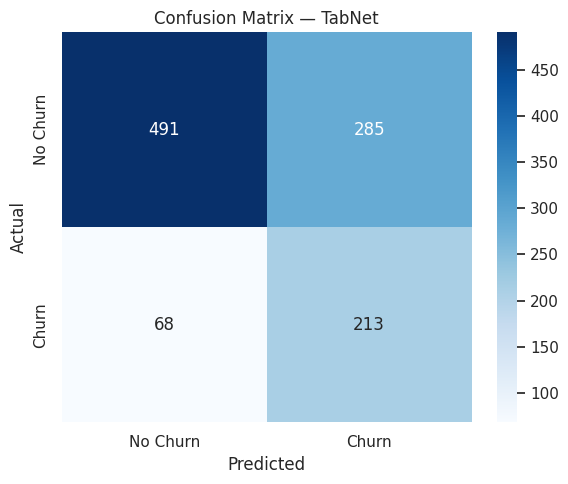

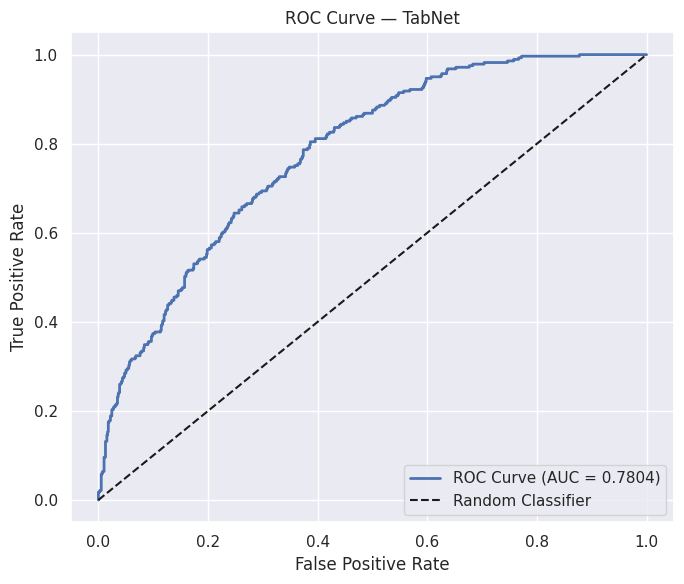

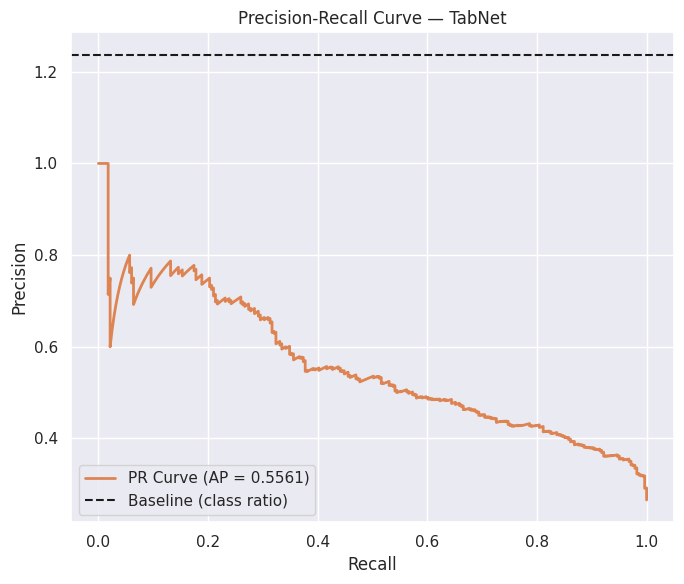

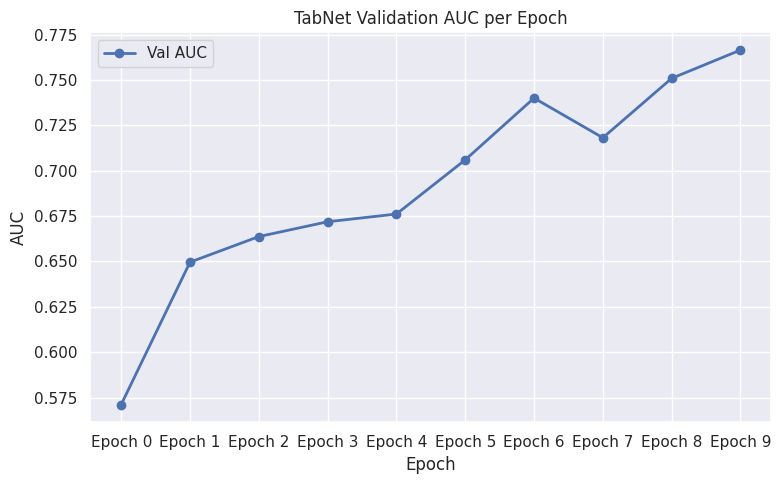

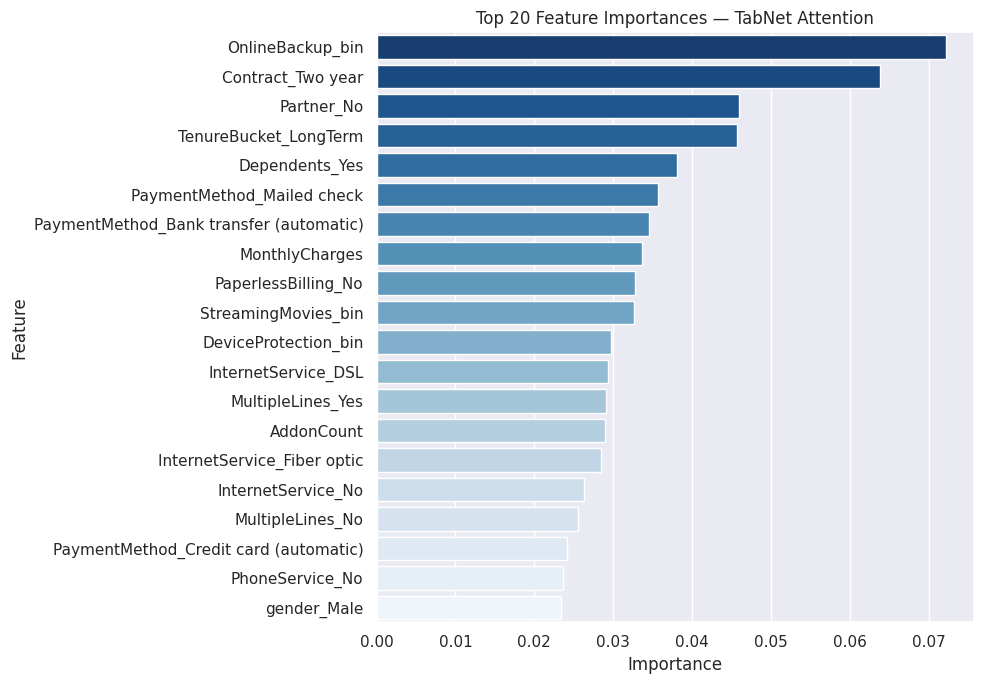

  0%|          | 0/100 [00:00<?, ?it/s]

Full shap_array shape: (100, 39, 2)


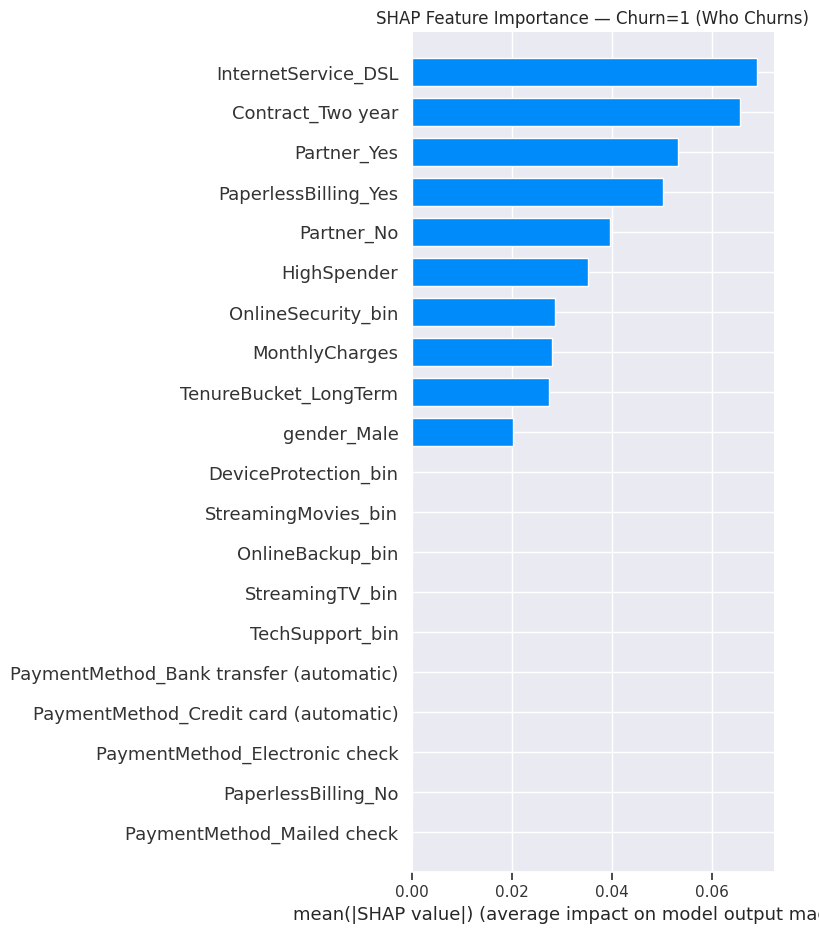

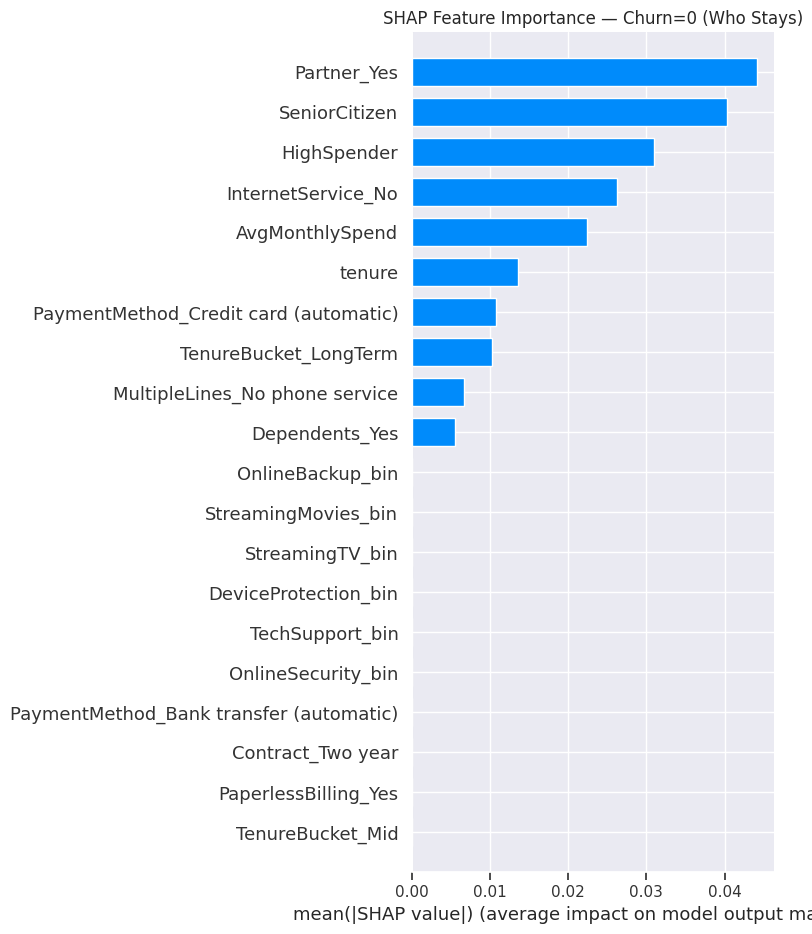

AssertionError: Feature and SHAP matrices must have the same number of rows!

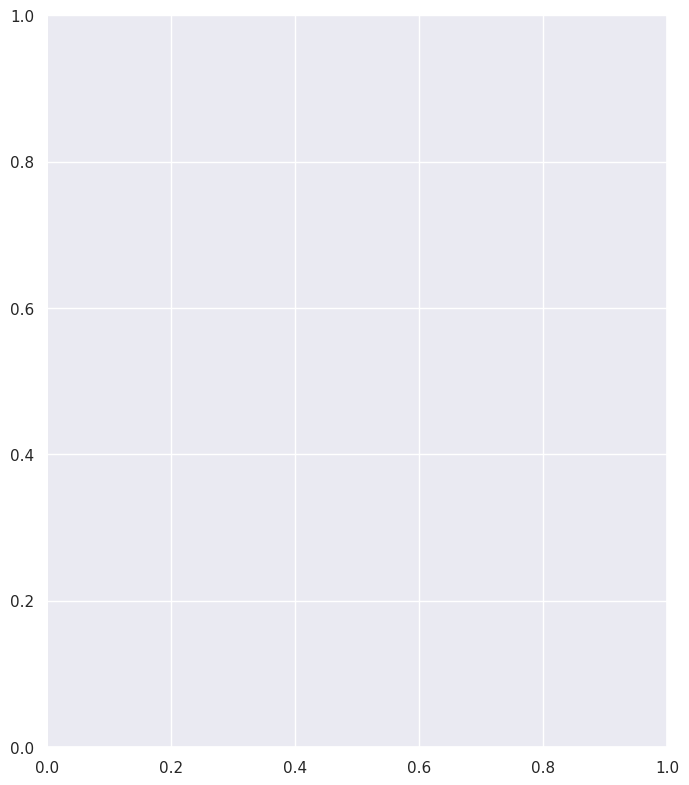

In [ ]:
# =============================================================================
# 11. EVALUATION
# =============================================================================

# --- Predictions ---
y_pred       = tabnet.predict(X_test)
y_pred_proba = tabnet.predict_proba(X_test)[:, 1]

# --- Metrics ---
print("\n" + "="*55)
print("CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

roc_auc = roc_auc_score(y_test, y_pred_proba)
avg_prec = average_precision_score(y_test, y_pred_proba)
print(f"ROC-AUC Score : {roc_auc:.4f}")
print(f"Avg Precision : {avg_prec:.4f}")


# --- 6.1 Confusion Matrix ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix — TabNet')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('tabnet_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


# --- 6.2 ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#4C72B0', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — TabNet')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('tabnet_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


# --- 6.3 Precision-Recall Curve ---
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, color='#DD8452', lw=2,
         label=f'PR Curve (AP = {avg_prec:.4f})')
plt.axhline(y=pos / len(y_test), color='k', linestyle='--',
            lw=1.5, label='Baseline (class ratio)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — TabNet')
plt.legend()
plt.tight_layout()
plt.savefig('tabnet_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()


# --- 6.4 Validation Accuracy ---

val_auc_scores = auc_callback.val_auc_history

plt.figure(figsize=(8, 5))
plt.plot(val_auc_scores, color='#4C72B0', lw=2, marker='o', label='Val AUC')
plt.xticks(range(len(val_auc_scores)),
           [f'Epoch {i}' for i in range(len(val_auc_scores))])
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('TabNet Validation AUC per Epoch')
plt.legend()
plt.tight_layout()
plt.savefig('tabnet_training_history.png', dpi=150, bbox_inches='tight')
plt.show()


# --- 6.5 Feature Importance (TabNet attention weights) ---
feature_importances = tabnet.feature_importances_

num_feat_names = numerical_features
ohe_feat_names = preprocessor.named_transformers_['cat']['encoder']\
                     .get_feature_names_out(categorical_features).tolist()
bin_feat_names = binary_features

feat_names = num_feat_names + ohe_feat_names + bin_feat_names

feat_imp_df = pd.DataFrame({
    'Feature': feat_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Top 20 Feature Importances — TabNet Attention')
plt.tight_layout()
plt.savefig('tabnet_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 6.6 SHAP Values for Class-Specific Importance ---

background = shap.sample(X_train, 100)  # 100 samples as background

explainer = shap.KernelExplainer(tabnet.predict_proba, background)
shap_values = explainer.shap_values(X_test[:100], nsamples=100)

shap_array = np.array(shap_values)  # shape: (2, 39, 2) or similar
print("Full shap_array shape:", shap_array.shape)  # add this to confirm

shap_churn    = shap_array[1].T   # shape becomes (100, 39)
shap_no_churn = shap_array[0].T   # shape becomes (100, 39)

# --- SHAP Summary Plot for Churn=1 ---
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_churn, X_test[:100],
                  feature_names=feat_names,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Churn=1 (Who Churns)')
plt.tight_layout()
plt.savefig('shap_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# --- SHAP Summary Plot for Churn=0 ---
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_no_churn, X_test[:100],
                  feature_names=feat_names,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Churn=0 (Who Stays)')
plt.tight_layout()
plt.savefig('shap_no_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# --- SHAP Dot Plot for Churn=1 (shows direction + magnitude) ---
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_churn, X_test[:100],
                  feature_names=feat_names,
                  plot_type='dot', show=False)
plt.title('SHAP Dot Plot — Feature Impact on Churn=1')
plt.tight_layout()
plt.savefig('shap_dot_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# =============================================================================
# 8. SAVE MODEL
# =============================================================================

tabnet.save_model('tabnet_churn_model')
print("\n✅ Model saved as: tabnet_churn_model.zip")
print("To load it later: tabnet.load_model('tabnet_churn_model.zip')")

Successfully saved model at tabnet_churn_model.zip

✅ Model saved as: tabnet_churn_model.zip
To load it later: tabnet.load_model('tabnet_churn_model.zip')
